In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('2019-Oct.csv', nrows=200000)
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d


In [4]:
df.info()
df["event_type"].value_counts()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   event_time     200000 non-null  object 
 1   event_type     200000 non-null  object 
 2   product_id     200000 non-null  int64  
 3   category_id    200000 non-null  int64  
 4   category_code  135756 non-null  object 
 5   brand          171489 non-null  object 
 6   price          200000 non-null  float64
 7   user_id        200000 non-null  int64  
 8   user_session   200000 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 13.7+ MB


event_type
view        193377
purchase      3639
cart          2984
Name: count, dtype: int64

In [5]:
df["event_time"]=pd.to_datetime(df["event_time"])
df=df[df["event_type"].isin(["view","cart","purchase"])]
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00+00:00,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00+00:00,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01+00:00,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01+00:00,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04+00:00,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d


FUNNEL ANALYSIS 

In [7]:
funnel_counts=df["event_type"].value_counts()
views=funnel_counts.get("view",0)
cart=funnel_counts.get("cart",0)
purchase=funnel_counts.get("purchase",0)
print("views:",views)
print("cart:",cart)
print("purchase:",purchase)

views: 193377
cart: 2984
purchase: 3639


CONVERSION RATES

In [8]:
view_to_cart=cart/views
cart_to_purchase=purchase/cart
overall_conversion=purchase/views
print("View → Cart:", view_to_cart)
print("Cart → Purchase:", cart_to_purchase)
print("Overall Conversion:", overall_conversion)

View → Cart: 0.015430997481603294
Cart → Purchase: 1.219504021447721
Overall Conversion: 0.018818163483764874


VISUALIZATION

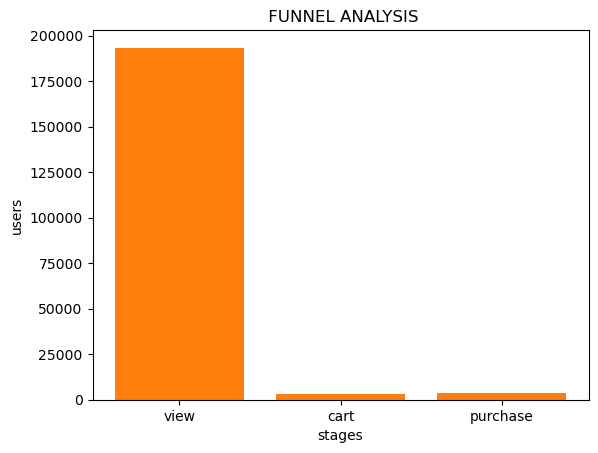

In [9]:
import matplotlib.pyplot as plt
stages=["view","cart","purchase"]
values=[views,cart,purchase]
plt.figure()
plt.bar(stages,values)
plt.bar(stages,values)
plt.title(" FUNNEL ANALYSIS")
plt.xlabel("stages")
plt.ylabel("users")
plt.show()

### Funnel Analysis Insight

There is a significant drop-off between product views and purchases, indicating friction in the user journey.

Business Recommendation:
- Improve product page experience
- Simplify checkout process
- Offer discounts or incentives

CREATE A/B GROUPS

In [10]:
np.random.seed(42)
df["group"]=np.random.choice(["a","b"],size=len(df))
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,group
0,2019-10-01 00:00:00+00:00,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c,a
1,2019-10-01 00:00:00+00:00,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc,b
2,2019-10-01 00:00:01+00:00,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8,a
3,2019-10-01 00:00:01+00:00,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713,a
4,2019-10-01 00:00:04+00:00,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d,a


In [29]:
user_conversion = df.groupby(['user_id', 'group'])['is_purchase'].max().reset_index()

In [30]:
user_conversion['is_purchase'].value_counts()

is_purchase
0    57113
1     3149
Name: count, dtype: int64

In [31]:
user_conversion.groupby('group')['is_purchase'].mean()

group
a    0.052070
b    0.052441
Name: is_purchase, dtype: float64

In [32]:
from statsmodels.stats.proportion import proportions_ztest

In [33]:
# Count purchases
success = user_conversion.groupby('group')['is_purchase'].sum()

# Total users
total = user_conversion.groupby('group')['is_purchase'].count()

# Convert to arrays
success = success.values
total = total.values

from statsmodels.stats.proportion import proportions_ztest

z_stat, p_value = proportions_ztest(success, total)

print("Z-stat:", z_stat)
print("P-value:", p_value)

Z-stat: -0.20439516117687992
P-value: 0.8380447111935899


### A/B Testing Insight

A proportion Z-test was conducted to compare conversion rates between Group A and Group B.

The p-value (0.83) is significantly higher than 0.05, indicating that there is no statistically significant difference between the two groups.

This suggests that the changes between the variants do not meaningfully impact user conversion.

Business Recommendation:
- Do not implement changes based on this experiment
- Test new variations with more impactful design or feature changes
- Continue experimentation to identify improvements in conversion rates